## Argo Float Asset Generator

 - [X] Find documentation for Argo API
 - [X] Write (or find) python function to pull Argo float data
 - [ ] Adapt openspace_rv function to generate assets
 - [ ] Investigate nonlinear pointcloud scaling
 - [ ] 

## Fetch Argo Data
Let's do this with argopy.

In [1]:
# import os
# import certifi
# os.environ['SSL_CERT_FILE'] = certifi.where()
# os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()


In [2]:
# import aiohttp
# import ssl
#
# # Create a context that doesn't verify certificates
# ssl_context = ssl.create_default_context()
# ssl_context.check_hostname = False
# ssl_context.verify_mode = ssl.CERT_NONE
#
# async with aiohttp.ClientSession(connector=aiohttp.TCPConnector(ssl=ssl_context)) as session:
#     ds = ArgoSet.load().data


NameError: name 'ArgoSet' is not defined

In [34]:
# Import the main data fetcher:
from argopy import DataFetcher
# Define what you want to fetch... 
# a region: [lon_min, lon_max, lat_min, lat_max, dpt_min, dpt_max]
ArgoSet = DataFetcher().region([-179.3866055, -173.5295458, -24.1034499, -15.3655722, 0, 1000, '2025-01-01', '2027-01-31'])
# floats:
# ArgoSet = DataFetcher().float([6902746, 6902747, 6902757, 6902766])
# or specific profiles:
# ArgoSet = DataFetcher().profile(6902746, 34)

In [35]:
# then fetch and get data as xarray datasets:
ds = ArgoSet.load().data
# or
ds = ArgoSet.to_xarray()
ds

<xarray.Dataset> Size: 8MB
Dimensions:          (N_POINTS: 67456)
Coordinates:
    LATITUDE         (N_POINTS) float64 540kB -19.84 -19.84 ... -23.97 -23.97
    LONGITUDE        (N_POINTS) float64 540kB -176.7 -176.7 ... -177.6 -177.6
    TIME             (N_POINTS) datetime64[ns] 540kB 2025-01-03T12:44:56 ... ...
  * N_POINTS         (N_POINTS) int64 540kB 0 1 2 3 ... 67452 67453 67454 67455
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 540kB 262 262 262 262 ... 310 310 310 310
    DATA_MODE        (N_POINTS) <U1 270kB 'D' 'D' 'D' 'D' ... 'A' 'A' 'A' 'A'
    DIRECTION        (N_POINTS) <U1 270kB 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 540kB 5905262 5905262 ... 5905262 5905262
    POSITION_QC      (N_POINTS) int64 540kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 270kB 1.08 2.08 3.08 ... 998.0 1e+03
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 270kB 0.01 0.01 0.01 ... nan nan nan
    PSAL_QC          (N_POINTS) int64 540kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 270kB 27.43 27.43 27.43 ... 4.41 4.4
    TEMP_ERROR       (N_POINTS) float32 270kB 0.002 0.002 0.002 ... nan nan nan
    TEMP_QC          (N_POINTS) int64 540kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 540kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           kristina
    Fetched_date:         2026/05/12
    Fetched_constraints:  [x=-179.39/-173.53; y=-24.10/-15.37; z=0.0/1000.0; ...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [31]:
# ds.var

<bound method DatasetAggregations.var of <xarray.Dataset> Size: 78MB
Dimensions:          (N_POINTS: 647485)
Coordinates:
    LATITUDE         (N_POINTS) float64 5MB -21.07 -21.07 ... -23.97 -23.97
    LONGITUDE        (N_POINTS) float64 5MB -176.2 -176.2 ... -177.6 -177.6
    TIME             (N_POINTS) datetime64[ns] 5MB 2020-01-01T02:52:30 ... 20...
  * N_POINTS         (N_POINTS) int64 5MB 0 1 2 3 ... 647482 647483 647484
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 5MB 34 34 34 34 34 ... 310 310 310 310 310
    DATA_MODE        (N_POINTS) <U1 3MB 'D' 'D' 'D' 'D' 'D' ... 'A' 'A' 'A' 'A'
    DIRECTION        (N_POINTS) <U1 3MB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 5MB 6902985 6902985 ... 5905262 5905262
    POSITION_QC      (N_POINTS) int64 5MB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 3MB 3.0 4.3 5.0 ... 996.0 998.0 1e+03
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 3MB

In [32]:
# ds.TIME

<xarray.DataArray 'TIME' (N_POINTS: 647485)> Size: 5MB
array(['2020-01-01T02:52:30.000000000', '2020-01-01T02:52:30.000000000',
       '2020-01-01T02:52:30.000000000', ...,
       '2026-04-28T04:28:04.000000000', '2026-04-28T04:28:04.000000000',
       '2026-04-28T04:28:04.000000000'],
      shape=(647485,), dtype='datetime64[ns]')
Coordinates:
    LATITUDE   (N_POINTS) float64 5MB -21.07 -21.07 -21.07 ... -23.97 -23.97
    LONGITUDE  (N_POINTS) float64 5MB -176.2 -176.2 -176.2 ... -177.6 -177.6
    TIME       (N_POINTS) datetime64[ns] 5MB 2020-01-01T02:52:30 ... 2026-04-...
  * N_POINTS   (N_POINTS) int64 5MB 0 1 2 3 4 ... 647481 647482 647483 647484
Attributes:
    _CoordinateAxisType:  Time
    actual_range:         [1.57784715e+09 1.77735048e+09]
    axis:                 T
    ioos_category:        Time
    long_name:            Julian day (UTC) of the station relative to REFEREN...
    standard_name:        time
    time_origin:          01-JAN-1970 00:00:00
    casted:               1

(<Figure size 900x540 with 1 Axes>,
 <Axes: xlabel='longitude', ylabel='latitude'>)

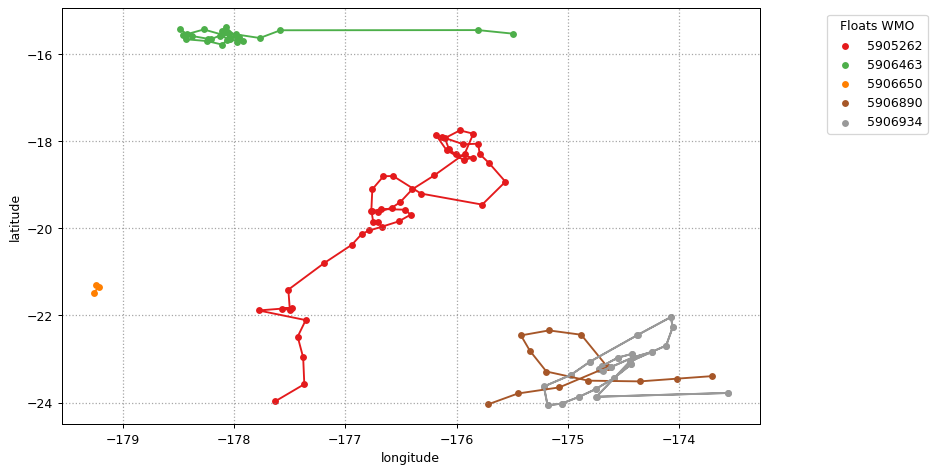

In [37]:
# you can even plot some information:
ArgoSet.plot('trajectory')